In [24]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [6]:
df=pd.read_csv("winequality.csv")
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
df.isna().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [7]:
# Handle missing values
df = df.fillna(df.mean(numeric_only=True))
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)
df = df.drop('quality', axis=1)

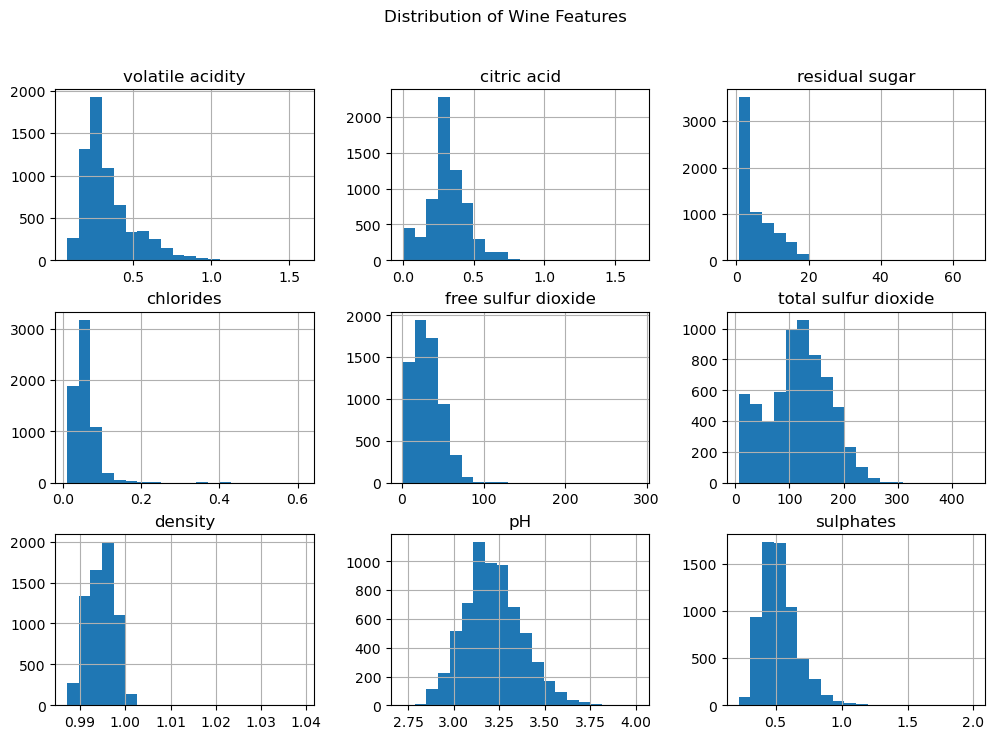

In [29]:
df.iloc[:,2:11].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Wine Features")
plt.show()

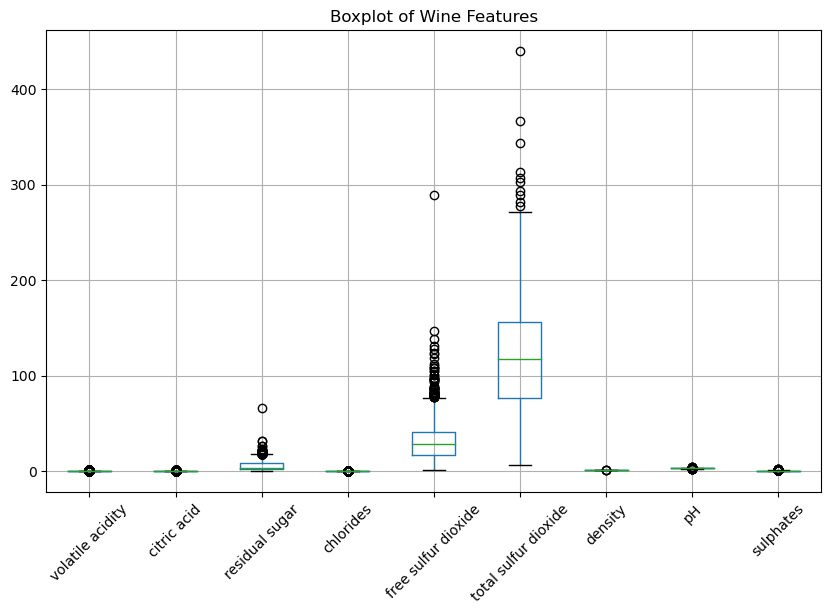

In [28]:
df.iloc[:,2:11].boxplot(figsize=(10,6))
plt.title("Boxplot of Wine Features")
plt.xticks(rotation=45)
plt.show()

In [8]:
X = df.drop('quality_label', axis=1)
y = df['quality_label']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation='relu',
    max_iter=50,
    random_state=42
)

mlp.fit(X_train, y_train)

C:\Users\kotta\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,50
,shuffle,True
,random_state,42


In [18]:
y_pred = mlp.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.796923076923077
Precision: 0.8389021479713604
Recall: 0.8449519230769231


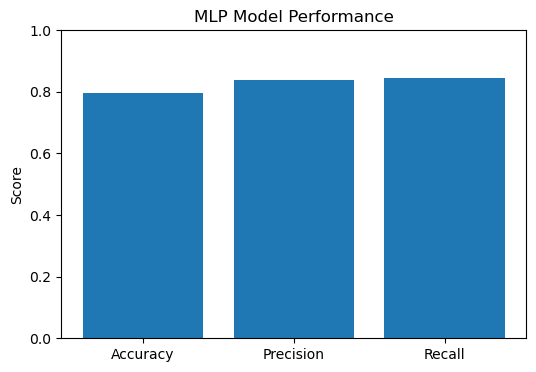

In [20]:
metrics = ['Accuracy','Precision','Recall']
values = [accuracy, precision, recall]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("MLP Model Performance")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

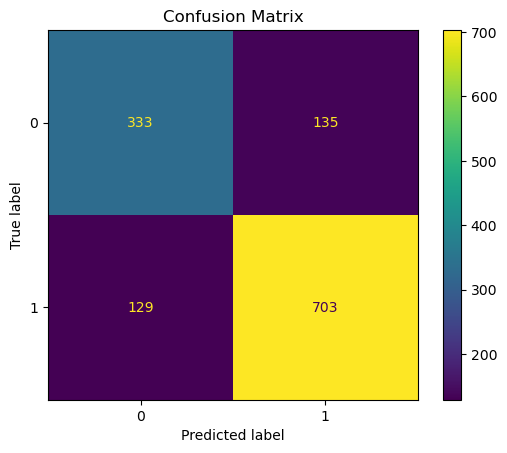

In [21]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()